In [2]:
# Importing the clean training and testing dataset

import pandas as pd

train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

In [4]:
print(len(train))
print(len(test))

76889
19223


In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Identify binary columns and continuous columns for scaling

binary_cols = [c for c in train.columns if set(pd.unique(train[c].dropna())) <= {0, 1}]
cont_cols   = [c for c in train.columns if c not in binary_cols]

preprocess = ColumnTransformer(
    transformers=[
        ("scale", StandardScaler(), cont_cols),
        ("keep_bin", "passthrough", binary_cols),
    ]
)

# Fitting the data (it becomes an array)

train_scaled_array = preprocess.fit_transform(train) 
test_scaled_array = preprocess.transform(test)

# Convert the arrays back into dataframes

new_cols = cont_cols + binary_cols  
train_scaled = pd.DataFrame(train_scaled_array, columns=new_cols, index=train.index)
test_scaled  = pd.DataFrame(test_scaled_array,  columns=new_cols, index=test.index)


In [6]:
train_scaled.head()

,age,bmi,HbA1c_level,blood_glucose_level,hypertension,heart_disease,diabetes,female,male,other,current,ever,former,never,no info,not current
0,0.141014,2.521511,-1.429243,1.514969,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,0.141014,0.390141,0.435572,0.486562,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,0.674635,0.403462,2.486868,2.984121,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,1.697407,-0.447605,0.622053,0.486562,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,-0.926226,0.829736,-0.683317,0.045817,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [7]:
# Splitting the scaled data into "X" matrix (input) and "Y" matrix (true outcome)

train_input = train_scaled.drop(['diabetes','other'], axis = 1)
train_output = train_scaled[['diabetes']]

test_input = test_scaled.drop(['diabetes','other'], axis = 1)
test_output = test_scaled[['diabetes']]

In [8]:
print(f'Training input: {len(train_input)} rows.')
print(f'Training output: {len(train_output)} rows.')

Training input: 76889 rows.
Training output: 76889 rows.


In [14]:
import tensorflow as tf
from tensorflow.keras.metrics import Precision, AUC

# Initialising and adding layers
# First test architecture 14 14 14 1

ann = tf.keras.models.Sequential()
ann.add(tf.keras.layers.Dense(units=14, activation='relu'))
ann.add(tf.keras.layers.Dense(units=14, activation='relu'))
ann.add(tf.keras.layers.Dense(units=1, activation="sigmoid"))

# Early stopping function, if there is no improvements are 10 consecutive epochs, stop the iteration.

callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss',
                                              patience=10)

# Compiling ANN
# Use "adam" for back propagation optimiser
# Use "binary_crossentropy" for calculating loss in classification problem
# Measure metrics such as "accuracy", "precision", "AUC"

ann.compile(optimizer="adam", loss="binary_crossentropy", 
            metrics=['accuracy', Precision(), AUC()])

#Fitting ANN, try 100 epochs with early stopping

model = ann.fit(train_input, train_output, batch_size=32, 
                validation_split = 0.2, epochs = 100, callbacks=[callback])



Epoch 1/100
1923/1923 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9495 - auc_3: 0.9392 - loss: 0.1475 - precision_3: 0.8070 - val_accuracy: 0.9624 - val_auc_3: 0.9647 - val_loss: 0.1107 - val_precision_3: 0.9018
Epoch 2/100
1923/1923 ━━━━━━━━━━━━━━━━━━━━ 2s 848us/step - accuracy: 0.9585 - auc_3: 0.9586 - loss: 0.1194 - precision_3: 0.8618 - val_accuracy: 0.9631 - val_auc_3: 0.9652 - val_loss: 0.1085 - val_precision_3: 0.9273
Epoch 3/100
1923/1923 ━━━━━━━━━━━━━━━━━━━━ 2s 821us/step - accuracy: 0.9602 - auc_3: 0.9603 - loss: 0.1148 - precision_3: 0.8858 - val_accuracy: 0.9670 - val_auc_3: 0.9692 - val_loss: 0.1005 - val_precision_3: 0.9119
Epoch 4/100
1923/1923 ━━━━━━━━━━━━━━━━━━━━ 2s 829us/step - accuracy: 0.9645 - auc_3: 0.9657 - loss: 0.1050 - precision_3: 0.9299 - val_accuracy: 0.9692 - val_auc_3: 0.9729 - val_loss: 0.0917 - val_precision_3: 0.9525
Epoch 5/100
1923/1923 ━━━━━━━━━━━━━━━━━━━━ 2s 857us/step - accuracy: 0.9672 - auc_3: 0.9690 - loss: 0.0983 - precision_3: 0.9611 - val

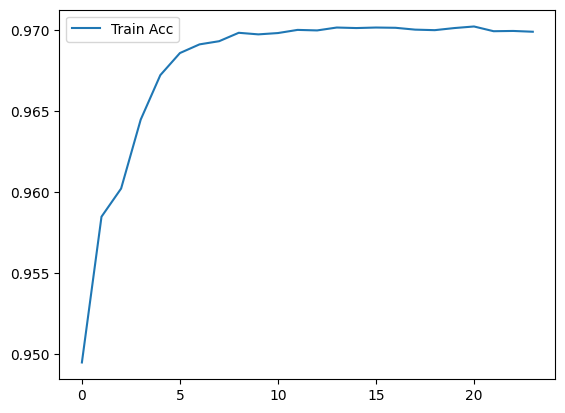

In [15]:
import matplotlib.pyplot as plt

plt.plot(model.history['accuracy'], label='Train Acc')
plt.legend(); plt.show()

In [16]:
ann.evaluate(test_input, test_output)

601/601 ━━━━━━━━━━━━━━━━━━━━ 0s 602us/step - accuracy: 0.9706 - auc_3: 0.9764 - loss: 0.0871 - precision_3: 0.9616


[0.08706262707710266, 0.970608115196228, 0.9615692496299744, 0.976423978805542]

In [ ]:
y_pred_proba = ann.predict(test_input, verbose=0).squeeze()
y_pred = pd.DataFrame({"diabetes_pred": y_pred_proba}, index = test_output.index)

prediction_binary = pd.concat([test_output, y_pred], axis = 1)


In [ ]:
# Save the predicted and true outcome data frame into a file for analysis
# Save the training history metrics

# prediction_binary.to_csv("predictions_binary.csv", index=False)

# pd.DataFrame(model.history).to_csv("training_history.csv", index=False)